conda install wfdb numpy pandas joblib tqdm tsai PyWavelets optuna tprch

In [15]:
# import numpy as np
# import pandas as pd
# import torch
# import psutil
# import wfdb
# import ast
# import os
# import random
# import shutil
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# from sklearn.model_selection import train_test_split
# import matplotlib
# import seaborn as sns
# from tqdm import tqdm
# from scipy.signal import resample
# from sklearn.metrics import f1_score, confusion_matrix, precision_recall_fscore_support

# # Check installed versions
# print("NumPy version:", np.__version__)
# print("Pandas version:", pd.__version__)
# print("Torch version:", torch.__version__)
# print("Psutil version:", psutil.__version__)
# print("WFDB version:", wfdb.__version__)
# print("Matplotlib version:", matplotlib.__version__)  # Access version from matplotlib module
# print("Seaborn version:", sns.__version__)
# try:
#     print("TQDM version:", tqdm.__version__)  # TQDM version
# except AttributeError:
#     print("TQDM version could not be found.")
# print("Scipy version:", resample.__module__.split()[0])
# print("Scikit-learn version:", f1_score.__module__.split()[0])


In [16]:
# import pandas as pd
# import numpy as np
# import wfdb
# import ast
# import os

# # Function to load raw ECG signal data based on sampling rate (100 Hz or 500 Hz)
# def load_raw_data(df, base_path, sample_rate='100'):
#     data = []

#     # Choose the appropriate filename column based on sample_rate
#     if sample_rate == '100':
#         filenames = df.filename_lr  # 100 Hz data
#     elif sample_rate == '500':
#         filenames = df.filename_hr  # 500 Hz data

#     for f in filenames:
#         # Since filenames already contain subdirectories, use base path only
#         full_path = os.path.join(base_path, f)
#         signal, meta = wfdb.rdsamp(full_path)
#         data.append(signal)

#     return np.array(data)

# # Set the base path (without records100 or records500 since it's already included in the filenames)
# BASE_PATH = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'

# # Load and process annotation data
# print("Loading annotation data...")
# Y = pd.read_csv(os.path.join(BASE_PATH, 'ptbxl_database.csv'), index_col='ecg_id')
# print("Annotation data loaded.")

# # Convert diagnostic codes from string to dictionary format
# print("Converting diagnostic codes...")
# Y['scp_codes'] = Y['scp_codes'].apply(ast.literal_eval)
# print("Diagnostic codes converted.")

# # Load and filter scp_statements.csv for diagnostic aggregation
# print("Loading diagnostic aggregation data...")
# agg_df = pd.read_csv(os.path.join(BASE_PATH, 'scp_statements.csv'), index_col=0)
# agg_df = agg_df[agg_df.diagnostic == 1]
# print("Diagnostic aggregation data loaded and filtered.")

# # Function to aggregate diagnostics into superclasses
# def aggregate_diagnostic(scp_codes_dict):
#     diagnostic_classes = [agg_df.loc[code].diagnostic_class
#                           for code in scp_codes_dict.keys()
#                           if code in agg_df.index]
#     return list(set(diagnostic_classes))

# # Apply diagnostic superclass aggregation to annotation data
# print("Aggregating diagnostic superclasses...")
# Y['diagnostic_superclass'] = Y['scp_codes'].apply(aggregate_diagnostic)
# print("Finished aggregating diagnostic superclasses.")

# # Prepare file names and paths for saving
# print("Preparing file paths and disease classes...")
# file_data = []

# for idx, row in Y.iterrows():
#     # Get the filename for 100 Hz and 500 Hz data
#     filename_lr = row['filename_lr']  # 100 Hz data
#     filename_hr = row['filename_hr']  # 500 Hz data

#     # Construct the full paths
#     full_path_lr = os.path.join(BASE_PATH, filename_lr)
#     full_path_hr = os.path.join(BASE_PATH, filename_hr)

#     # Extract the base name to construct .dat and .hea file names for both 100 Hz and 500 Hz
#     base_filename_lr = os.path.splitext(filename_lr)[0]
#     base_filename_hr = os.path.splitext(filename_hr)[0]

#     # Add to list for creating DataFrame
#     file_data.append({
#         'disease_class': row['diagnostic_superclass'],
#         'dat_file_100Hz': f"{base_filename_lr}.dat",
#         'hea_file_100Hz': f"{base_filename_lr}.hea",
#         'file_path_100Hz': full_path_lr,
#         'dat_file_500Hz': f"{base_filename_hr}.dat",
#         'hea_file_500Hz': f"{base_filename_hr}.hea",
#         'file_path_500Hz': full_path_hr
#     })

# # Convert the list to a DataFrame
# csv_data = pd.DataFrame(file_data)

# # Save to CSV
# csv_file_path = os.path.join(BASE_PATH, 'ptbxl_disease_file_info.csv')
# csv_data.to_csv(csv_file_path, index=False)
# print(f"CSV file saved at: {csv_file_path}")



In [17]:
# import pandas as pd

# # Function to load the CSV and delete rows with paired classes, saving to a new file
# def remove_paired_classes(csv_path, output_csv_path):
#     # Load the original CSV file
#     csv_data = pd.read_csv(csv_path)

#     # Filter out rows with paired classes (i.e., more than one class)
#     filtered_data = csv_data[csv_data['disease_class'].apply(lambda x: len(eval(x)) == 1)]

#     # Save the filtered data to a new CSV file
#     filtered_data.to_csv(output_csv_path, index=False)

#     print(f"Filtered data saved to {output_csv_path}")

# if __name__ == "__main__":
#     # Set the paths
#     csv_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptbxl_disease_file_info.csv'  # Path to your original CSV file
#     output_csv_path =  r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptbxl_filtered_disease_file_info.csv'  # Path to save the filtered CSV file

#     # Remove rows with paired classes and save the result as a new CSV file
#     remove_paired_classes(csv_path, output_csv_path)


In [18]:
# import pandas as pd
# import numpy as np
# import wfdb
# import ast
# import os

# # Function to load raw ECG signal data based on sampling rate (100 Hz or 500 Hz)
# def load_raw_data(df, base_path, sample_rate='100'):
#     data = []

#     # Choose the appropriate filename column based on sample_rate
#     if sample_rate == '100':
#         filenames = df.filename_lr  # 100 Hz data
#     elif sample_rate == '500':
#         filenames = df.filename_hr  # 500 Hz data

#     for f in filenames:
#         # Since filenames already contain subdirectories, use base path only
#         full_path = os.path.join(base_path, f)
#         signal, meta = wfdb.rdsamp(full_path)
#         data.append(signal)

#     return np.array(data)

# # Set the base path (without records100 or records500 since it's already included in the filenames)
# BASE_PATH = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'

# # Load and process annotation data
# print("Loading annotation data...")
# Y = pd.read_csv(os.path.join(BASE_PATH, 'ptbxl_database.csv'), index_col='ecg_id')
# print("Annotation data loaded.")

# # Convert diagnostic codes from string to dictionary format
# print("Converting diagnostic codes...")
# Y['scp_codes'] = Y['scp_codes'].apply(ast.literal_eval)
# print("Diagnostic codes converted.")

# # Load and filter scp_statements.csv for diagnostic aggregation
# print("Loading diagnostic aggregation data...")
# agg_df = pd.read_csv(os.path.join(BASE_PATH, 'scp_statements.csv'), index_col=0)
# agg_df = agg_df[agg_df.diagnostic == 1]
# print("Diagnostic aggregation data loaded and filtered.")

# # Function to aggregate diagnostics into superclasses
# def aggregate_diagnostic(scp_codes_dict):
#     diagnostic_classes = [agg_df.loc[code].diagnostic_class
#                           for code in scp_codes_dict.keys()
#                           if code in agg_df.index]
#     return list(set(diagnostic_classes))

# # Apply diagnostic superclass aggregation to annotation data
# print("Aggregating diagnostic superclasses...")
# Y['diagnostic_superclass'] = Y['scp_codes'].apply(aggregate_diagnostic)
# print("Finished aggregating diagnostic superclasses.")

# # Prepare file names and paths for saving
# print("Preparing file paths and disease classes...")
# file_data = []

# for idx, row in Y.iterrows():
#     # Get the filename for 100 Hz and 500 Hz data
#     filename_lr = row['filename_lr']  # 100 Hz data
#     filename_hr = row['filename_hr']  # 500 Hz data

#     # Construct the full paths
#     full_path_lr = os.path.join(BASE_PATH, filename_lr)
#     full_path_hr = os.path.join(BASE_PATH, filename_hr)

#     # Extract the base name to construct .dat and .hea file names for both 100 Hz and 500 Hz
#     base_filename_lr = os.path.splitext(filename_lr)[0]
#     base_filename_hr = os.path.splitext(filename_hr)[0]

#     # Add to list for creating DataFrame
#     file_data.append({
#         'disease_class': row['diagnostic_superclass'],
#         'dat_file_100Hz': f"{base_filename_lr}.dat",
#         'hea_file_100Hz': f"{base_filename_lr}.hea",
#         'file_path_100Hz': full_path_lr,
#         'dat_file_500Hz': f"{base_filename_hr}.dat",
#         'hea_file_500Hz': f"{base_filename_hr}.hea",
#         'file_path_500Hz': full_path_hr
#     })

# # Convert the list to a DataFrame
# csv_data = pd.DataFrame(file_data)

# # Save to CSV
# csv_file_path = os.path.join(BASE_PATH, 'ptbxl_disease_file_info.csv')
# csv_data.to_csv(csv_file_path, index=False)
# print(f"CSV file saved at: {csv_file_path}")

# import pandas as pd
# import os

# # Load the CSV file you created with the diagnostic and file information
# csv_file_path = os.path.join(BASE_PATH, 'ptbxl_disease_file_info.csv')
# csv_data = pd.read_csv(csv_file_path)

# # Count the total amount of data by each disease class
# # 'explode' is used to handle lists in the 'disease_class' column
# disease_class_counts = csv_data.explode('disease_class')['disease_class'].value_counts()

# # Display the counts
# print(disease_class_counts)

# # If you want to save this to a CSV file:
# disease_class_counts.to_csv(os.path.join(BASE_PATH, 'disease_class_counts.csv'), header=True)


In [19]:
# import pandas as pd

# # List of disease class combinations to remove
# classes_to_remove = [
#     ['MI', 'CD'], ['STTC', 'HYP'], ['MI', 'STTC'], ['STTC', 'CD'], [],
#     ['CD', 'NORM'], ['MI', 'STTC', 'HYP'], ['CD', 'HYP'], ['MI', 'STTC', 'CD'],
#     ['STTC', 'CD', 'HYP'], ['MI', 'HYP'], ['MI', 'STTC', 'CD', 'HYP'], ['MI', 'CD', 'HYP'],
#     ['STTC', 'NORM'], ['STTC', 'CD', 'NORM'], ['CD', 'NORM', 'HYP'], ['NORM', 'HYP'],
#     ['MI', 'CD', 'NORM', 'HYP']
# ]

# # Load the CSV file
# csv_file_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptbxl_disease_file_info.csv'
# csv_data = pd.read_csv(csv_file_path)

# # Filter out rows that have any of the disease classes in the list 'classes_to_remove'
# filtered_data = csv_data[~csv_data['disease_class'].apply(lambda x: eval(x) in classes_to_remove)]

# # Reprint the first few rows of the filtered data
# print(filtered_data.head())

# # Save the filtered data to a new CSV file
# filtered_csv_file_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptbxl_disease_file_info_filtered.csv'
# filtered_data.to_csv(filtered_csv_file_path, index=False)

# print(f"Filtered data saved to: {filtered_csv_file_path}")


In [20]:
# import pandas as pd

# # Path to the filtered CSV file
# filtered_csv_file_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptbxl_disease_file_info_filtered.csv'

# # Load the filtered CSV file
# filtered_data = pd.read_csv(filtered_csv_file_path)

# # Print the first few rows of the CSV file
# print(filtered_data.head())

# # If you want to print the entire CSV, use:
# # print(filtered_data.to_string()) # This will print the entire CSV, but be careful with large files.

# # You can also print specific information, like column names or a summary:
# print(filtered_data.info())  # Displays a summary of the data
# print(filtered_data.columns)  # Prints the column names


In [21]:
# import os
# import shutil
# import pandas as pd

# # Load the filtered CSV file
# csv_file_path = r"C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptbxl_disease_file_info_filtered.csv"
# csv_data = pd.read_csv(csv_file_path)

# # Define the base path where the .dat and .hea files are located
# base_dat_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'

# # Define the destination base path where files will be sorted according to their classes
# destination_base = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'

# # Log file to store missing files
# missing_files_log = os.path.join(destination_base, 'missing_files_log.txt')

# # Make sure the destination base folder exists
# os.makedirs(destination_base, exist_ok=True)

# # Move the .dat and .hea files to folders based on their disease classes
# with open(missing_files_log, 'w') as log_file:
#     for index, row in csv_data.iterrows():
#         # Get the disease class and dat file path for 100Hz
#         disease_class = eval(row['disease_class'])[0]  # Assuming single-class per record
#         dat_file_100Hz = row['dat_file_100Hz']  # Get the relative .dat file path for 100Hz

#         # Create the folder for this disease class if it doesn't exist
#         class_folder = os.path.join(destination_base, disease_class)
#         os.makedirs(class_folder, exist_ok=True)

#         # Build the full source path for the .dat file
#         full_dat_file_path = os.path.join(base_dat_path, dat_file_100Hz)

#         # Build the corresponding .hea file path (replace .dat with .hea)
#         full_hea_file_path = full_dat_file_path.replace('.dat', '.hea')

#         # Check if the .dat file exists before moving
#         if os.path.exists(full_dat_file_path):
#             # Move the .dat file to the appropriate class folder
#             destination_dat_file_path = os.path.join(class_folder, os.path.basename(full_dat_file_path))
#             shutil.move(full_dat_file_path, destination_dat_file_path)
#             print(f"Moved file {full_dat_file_path} to {destination_dat_file_path}")
#         else:
#             # Log missing .dat files if they do not exist
#             log_file.write(f"Missing .dat file: {full_dat_file_path}\n")
#             print(f"Missing .dat file: {full_dat_file_path}")

#         # Check if the corresponding .hea file exists before moving
#         if os.path.exists(full_hea_file_path):
#             # Move the .hea file to the appropriate class folder
#             destination_hea_file_path = os.path.join(class_folder, os.path.basename(full_hea_file_path))
#             shutil.move(full_hea_file_path, destination_hea_file_path)
#             print(f"Moved file {full_hea_file_path} to {destination_hea_file_path}")
#         else:
#             # Log missing .hea files if they do not exist
#             log_file.write(f"Missing .hea file: {full_hea_file_path}\n")
#             print(f"Missing .hea file: {full_hea_file_path}")

# print("Files moved according to disease classes, missing files logged.")


In [22]:
# import os
# # Define the destination base path where files will be sorted according to their classes
# destination_base = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'
# # Function to count the number of .dat and .hea files in each class folder
# def count_files_in_class_folders(destination_base):
#     print("\nCounting .dat and .hea files in each class folder:")
#     for folder in os.listdir(destination_base):
#         class_folder = os.path.join(destination_base, folder)
#         if os.path.isdir(class_folder):
#             # Count the number of .dat files in the class folder
#             dat_files = [f for f in os.listdir(class_folder) if f.endswith('.dat')]
#             # Count the number of .hea files in the class folder
#             hea_files = [f for f in os.listdir(class_folder) if f.endswith('.hea')]
#             print(f"{folder}: {len(dat_files)} .dat files, {len(hea_files)} .hea files")

# # Call the function to count the files
# count_files_in_class_folders(destination_base)


In [23]:
# import os
# import random
# import shutil

# # Function to balance the dataset by copying both .dat and .hea files for smaller classes
# def balance_dataset(destination_base, target_count):
#     print("\nBalancing dataset...")

#     for folder in os.listdir(destination_base):
#         class_folder = os.path.join(destination_base, folder)
#         if os.path.isdir(class_folder):
#             # List all the .dat and corresponding .hea files in the class folder
#             dat_files = [f for f in os.listdir(class_folder) if f.endswith('.dat')]
#             file_count = len(dat_files)

#             # If the number of files is less than the target count, duplicate files
#             if file_count < target_count:
#                 print(f"Balancing class {folder}: {file_count} files -> {target_count} files")

#                 # Randomly copy files to reach the target count
#                 while len(dat_files) < target_count:
#                     file_to_copy = random.choice(dat_files)  # Randomly select a .dat file to copy
#                     file_base_name = file_to_copy.replace('.dat', '')  # Get the base name (without .dat)

#                     # Define the new .dat and .hea file names
#                     new_dat_file_name = f"copy_{len(dat_files) + 1}_{file_to_copy}"
#                     new_hea_file_name = f"copy_{len(dat_files) + 1}_{file_base_name}.hea"

#                     # Define the source and destination file paths
#                     source_dat_file = os.path.join(class_folder, file_to_copy)
#                     source_hea_file = os.path.join(class_folder, f"{file_base_name}.hea")

#                     destination_dat_file = os.path.join(class_folder, new_dat_file_name)
#                     destination_hea_file = os.path.join(class_folder, new_hea_file_name)

#                     # Copy both .dat and .hea files (if .hea exists)
#                     shutil.copy(source_dat_file, destination_dat_file)  # Copy the .dat file
#                     if os.path.exists(source_hea_file):
#                         shutil.copy(source_hea_file, destination_hea_file)  # Copy the .hea file if it exists
#                     else:
#                         print(f"Warning: No matching .hea file for {file_to_copy}, skipping .hea copy.")

#                     dat_files.append(new_dat_file_name)  # Add the new file to the list

#                 print(f"Class {folder} balanced to {target_count} files.")

# # Function to count the .dat and .hea files in each class folder
# def count_files_in_class_folders(destination_base):
#     print("\nCounting files in each class folder:")
#     for folder in os.listdir(destination_base):
#         class_folder = os.path.join(destination_base, folder)
#         if os.path.isdir(class_folder):
#             dat_files = [f for f in os.listdir(class_folder) if f.endswith('.dat')]
#             hea_files = [f for f in os.listdir(class_folder) if f.endswith('.hea')]
#             print(f"Class {folder}: {len(dat_files)} .dat files and {len(hea_files)} .hea files")

# # Set the target count to the highest class count (NORM: 9083 files)
# target_count = 9083

# # Balance the dataset by duplicating both .dat and .hea files
# balance_dataset(destination_base, target_count)

# # Verify the new counts after balancing
# count_files_in_class_folders(destination_base)


In [24]:
# import os
# # Define the destination base path where files will be sorted according to their classes
# destination_base = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'
# # Function to count the number of .dat and .hea files in each class folder
# def count_files_in_class_folders(destination_base):
#     print("\nCounting .dat and .hea files in each class folder:")
#     for folder in os.listdir(destination_base):
#         class_folder = os.path.join(destination_base, folder)
#         if os.path.isdir(class_folder):
#             # Count the number of .dat files in the class folder
#             dat_files = [f for f in os.listdir(class_folder) if f.endswith('.dat')]
#             # Count the number of .hea files in the class folder
#             hea_files = [f for f in os.listdir(class_folder) if f.endswith('.hea')]
#             print(f"{folder}: {len(dat_files)} .dat files, {len(hea_files)} .hea files")

# # Call the function to count the files
# count_files_in_class_folders(destination_base)


In [25]:
# import os
# import random
# import shutil
# destination_base = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'
# # Function to balance the dataset by copying both .dat and .hea files for smaller classes
# def balance_dataset(destination_base, target_count):
#     print("\nBalancing dataset...")

#     for folder in os.listdir(destination_base):
#         class_folder = os.path.join(destination_base, folder)
#         if os.path.isdir(class_folder):
#             # List all the .dat and corresponding .hea files in the class folder
#             dat_files = [f for f in os.listdir(class_folder) if f.endswith('.dat')]
#             file_count = len(dat_files)

#             # If the number of files is less than the target count, duplicate files
#             if file_count < target_count:
#                 print(f"Balancing class {folder}: {file_count} files -> {target_count} files")

#                 # Randomly copy files to reach the target count
#                 while len(dat_files) < target_count:
#                     file_to_copy = random.choice(dat_files)  # Randomly select a .dat file to copy
#                     file_base_name = file_to_copy.replace('.dat', '')  # Get the base name (without .dat)

#                     # Define the new .dat and .hea file names
#                     new_dat_file_name = f"copy_{len(dat_files) + 1}_{file_to_copy}"
#                     new_hea_file_name = f"copy_{len(dat_files) + 1}_{file_base_name}.hea"

#                     # Define the source and destination file paths
#                     source_dat_file = os.path.join(class_folder, file_to_copy)
#                     source_hea_file = os.path.join(class_folder, f"{file_base_name}.hea")

#                     destination_dat_file = os.path.join(class_folder, new_dat_file_name)
#                     destination_hea_file = os.path.join(class_folder, new_hea_file_name)

#                     # Copy both .dat and .hea files (if .hea exists)
#                     shutil.copy(source_dat_file, destination_dat_file)  # Copy the .dat file
#                     if os.path.exists(source_hea_file):
#                         shutil.copy(source_hea_file, destination_hea_file)  # Copy the .hea file if it exists
#                     else:
#                         print(f"Warning: No matching .hea file for {file_to_copy}, skipping .hea copy.")

#                     dat_files.append(new_dat_file_name)  # Add the new file to the list

#                 print(f"Class {folder} balanced to {target_count} files.")

# # Function to count the .dat and .hea files in each class folder
# def count_files_in_class_folders(destination_base):
#     print("\nCounting files in each class folder:")
#     for folder in os.listdir(destination_base):
#         class_folder = os.path.join(destination_base, folder)
#         if os.path.isdir(class_folder):
#             dat_files = [f for f in os.listdir(class_folder) if f.endswith('.dat')]
#             hea_files = [f for f in os.listdir(class_folder) if f.endswith('.hea')]
#             print(f"Class {folder}: {len(dat_files)} .dat files and {len(hea_files)} .hea files")

# # Set the target count to the highest class count (NORM: 9083 files)
# target_count = 18166

# # Balance the dataset by duplicating both .dat and .hea files
# balance_dataset(destination_base, target_count)

# # Verify the new counts after balancing
# count_files_in_class_folders(destination_base)


In [26]:
# import os
# # Define the destination base path where files will be sorted according to their classes
# destination_base = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'
# # Function to count the number of .dat and .hea files in each class folder
# def count_files_in_class_folders(destination_base):
#     print("\nCounting .dat and .hea files in each class folder:")
#     for folder in os.listdir(destination_base):
#         class_folder = os.path.join(destination_base, folder)
#         if os.path.isdir(class_folder):
#             # Count the number of .dat files in the class folder
#             dat_files = [f for f in os.listdir(class_folder) if f.endswith('.dat')]
#             # Count the number of .hea files in the class folder
#             hea_files = [f for f in os.listdir(class_folder) if f.endswith('.hea')]
#             print(f"{folder}: {len(dat_files)} .dat files, {len(hea_files)} .hea files")

# # Call the function to count the files
# count_files_in_class_folders(destination_base)


In [27]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


Transformer arcitecture

Loading STTC data (100%): 100%|██████████| 18166/18166 [00:59<00:00, 304.59it/s]


Loaded 90830 samples with shape (90830, 500, 12)


c:\Users\zen3Node\anaconda3\envs\htet-gpu2\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Is CUDA available?  True
Device being used:  cuda
GPU Name:  NVIDIA RTX A6000

Epoch 1/100


Training: 100%|██████████| 1136/1136 [01:08<00:00, 16.69it/s]


...

Training loss: 0.0051, Training Accuracy: 0.9981
Validation loss: 0.2817, Testing Accuracy: 0.9734
Weighted F1 Score: 0.9733

Epoch 99/100


Training: 100%|██████████| 1136/1136 [01:02<00:00, 18.13it/s]


Training loss: 0.0063, Training Accuracy: 0.9979
Validation loss: 0.2746, Testing Accuracy: 0.9737
Weighted F1 Score: 0.9737

Epoch 100/100


Training: 100%|██████████| 1136/1136 [01:02<00:00, 18.14it/s]


Training loss: 0.0040, Training Accuracy: 0.9986
Validation loss: 0.2666, Testing Accuracy: 0.9738
Weighted F1 Score: 0.9738
Model saved to C:\Users\zen3Node\LEON\myenv\Models\transformer_ecg_model4layerx2datas(100Hz).pth


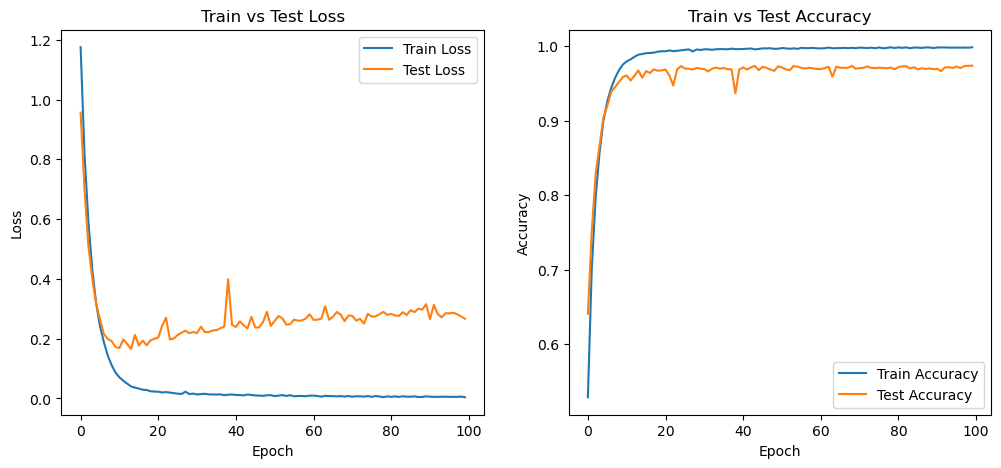

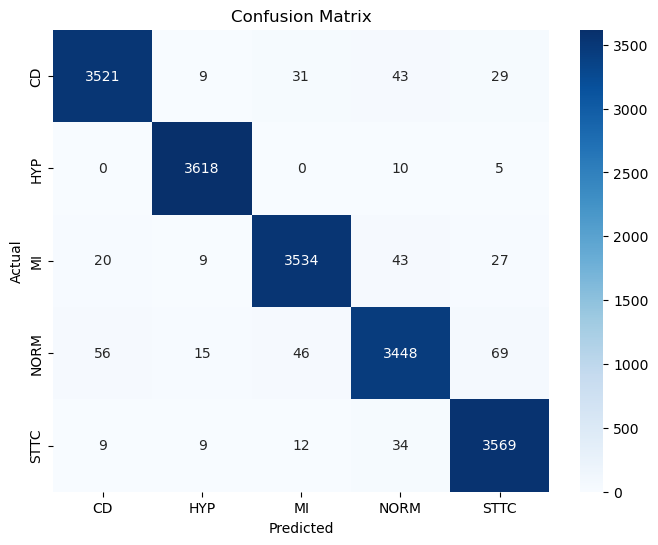

Classification Report:
              precision    recall  f1-score   support

          CD       0.98      0.97      0.97      3633
         HYP       0.99      1.00      0.99      3633
          MI       0.98      0.97      0.97      3633
        NORM       0.96      0.95      0.96      3634
        STTC       0.96      0.98      0.97      3633

    accuracy                           0.97     18166
   macro avg       0.97      0.97      0.97     18166
weighted avg       0.97      0.97      0.97     18166

Final Weighted F1 Score: 0.9738
Final Train Loss: 0.0040, Final Train Accuracy: 0.9986
Final Test Loss: 0.2666, Final Test Accuracy: 0.9738
Final Input Shape: (72664, 500, 12)


In [28]:
import os
import numpy as np
import wfdb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.signal import resample
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# Define your class folders and dataset path
sorted_dataset_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'
class_folders = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# Function to load data from each class folder
def load_class_data(sorted_dataset_path, class_folders, sample_rate=500, fraction=1):
    data = []
    labels = []
    errors = []

    for label_idx, class_folder in enumerate(class_folders):
        folder_path = os.path.join(sorted_dataset_path, class_folder)
        if not os.path.exists(folder_path):
            print(f"Folder {folder_path} does not exist.")
            continue

        files = [f for f in os.listdir(folder_path) if f.endswith('.dat')]
        if not files:
            print(f"No files found in {folder_path}.")
            continue

        num_files = int(len(files) * fraction)
        sampled_files = files[:num_files]

        for file in tqdm(sampled_files, desc=f"Loading {class_folder} data ({int(fraction * 100)}%)"):
            file_path = os.path.join(folder_path, file.replace('.dat', ''))
            try:
                # Load 12-lead ECG data
                signal, _ = wfdb.rdsamp(file_path)
                if signal.shape[1] != 12:
                    raise ValueError(f"Expected 12 leads, but got {signal.shape[1]}")

                # Resample or trim each lead to 500 samples
                signal_resampled = resample(signal, sample_rate)
                data.append(signal_resampled)
                labels.append(label_idx)
            except Exception as e:
                errors.append(file)
                print(f"Error loading {file}: {e}")

    if errors:
        print(f"Skipped {len(errors)} files due to errors.")

    return np.array(data), np.array(labels)

# Load the data
X_data, y_labels = load_class_data(sorted_dataset_path, class_folders, fraction=1)

# Normalize the data: zero mean and unit variance
X_data = (X_data - np.mean(X_data)) / np.std(X_data)

print(f"Loaded {X_data.shape[0]} samples with shape {X_data.shape}")

# Split the dataset into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

# Prepare the data for PyTorch by creating a Dataset and DataLoader
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Transpose data to have shape (sequence_length, num_features) for Transformer
        return torch.tensor(self.X[idx], dtype=torch.float32).transpose(0, 1), torch.tensor(self.y[idx], dtype=torch.long)

batch_size = 64
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define Transformer model for ECG classification
class TransformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, num_heads=4, num_layers=4, dim_feedforward=512, dropout=0.1, max_seq_len=500):
        super(TransformerModel, self).__init__()
        self.input_dim = input_dim
        self.max_seq_len = max_seq_len

        # Positional encoding (learned encoding with correct dimensions)
        self.positional_encoding = nn.Parameter(torch.randn(1, max_seq_len, input_dim))

        # Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(d_model=input_dim, nhead=num_heads, dim_feedforward=dim_feedforward, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Fully connected layers with added activation functions
        self.fc1 = nn.Linear(input_dim * max_seq_len, 128)  # Flatten 500 time steps with 12 leads
        self.activation1 = nn.ReLU()  # Activation function after the first fully connected layer
        self.fc2 = nn.Linear(128, 64)  # Adding another fully connected layer for more depth
        self.activation2 = nn.ReLU()  # Activation after second FC layer
        self.fc3 = nn.Linear(64, output_dim)  # Output layer

    def forward(self, x):
        # Transpose input to match the positional encoding shape
        x = x.transpose(1, 2)  # Now x is [batch_size, 500, 12]

        # Add positional encoding to the input
        x = x + self.positional_encoding[:, :x.size(1), :]

        # Transformer expects input in (sequence_length, batch_size, input_dim), so transpose accordingly
        x = x.transpose(0, 1)  # Convert to [sequence_length, batch_size, input_dim]

        # Pass through the transformer encoder
        x = self.transformer_encoder(x)

        # Flatten the output for fully connected layers
        x = x.transpose(0, 1).contiguous().view(x.size(1), -1)

        # Fully connected layers with activation functions
        x = self.fc1(x)
        x = self.activation1(x)
        x = self.fc2(x)
        x = self.activation2(x)
        x = self.fc3(x)

        return x

# Model, loss function, optimizer, and device setup
input_dim = X_train.shape[2]  # Number of ECG leads (12 leads)
output_dim = len(class_folders)  # Number of classes

model = TransformerModel(input_dim=input_dim, output_dim=output_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Is CUDA available? ", torch.cuda.is_available())
print("Device being used: ", device)
print("GPU Name: ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")


# Compute class weights for imbalanced datasets
class_weights = torch.tensor(np.bincount(y_train)).float().to(device)
class_weights = 1.0 / class_weights
class_weights = class_weights / class_weights.sum()  # Normalize the weights

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Reduced learning rate for better convergence

# Initialize lists to store loss and accuracy metrics
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
f1_scores = []

# Training loop
epochs = 100
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Training loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

    # Validation phase
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    test_loss /= len(test_loader)
    test_losses.append(test_loss)

    accuracy = correct / total
    test_accuracies.append(accuracy)

    print(f"Validation loss: {test_loss:.4f}, Testing Accuracy: {accuracy:.4f}")

    # Calculate F1 score
    f1 = f1_score(all_labels, all_preds, average='weighted')
    f1_scores.append(f1)

    print(f"Weighted F1 Score: {f1:.4f}")

# Save the trained model
model_save_path = r'C:\Users\zen3Node\LEON\myenv\Models\transformer_ecg_model4layerx2datas(100Hz).pth'
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# Plot training vs validation loss and accuracy
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()

plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_folders, yticklabels=class_folders)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Print classification report for precision, recall, and F1-score
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_folders))

# Print final weighted F1 score, final loss and accuracy, and final input shape
print(f"Final Weighted F1 Score: {f1_scores[-1]:.4f}")
print(f"Final Train Loss: {train_losses[-1]:.4f}, Final Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}, Final Test Accuracy: {test_accuracies[-1]:.4f}")
print(f"Final Input Shape: {X_train.shape}")


Prof Jeff Hilton Capsule

Epoch 1/100: 100%|██████████| 1136/1136 [00:24<00:00, 46.27it/s]


Validation Loss: 20.0464, Accuracy: 0.8786


Epoch 2/100: 100%|██████████| 1136/1136 [00:22<00:00, 50.93it/s]


Validation Loss: 16.4625, Accuracy: 0.9456


Epoch 3/100: 100%|██████████| 1136/1136 [00:22<00:00, 50.77it/s]


...

Validation Loss: 9.7484, Accuracy: 0.9758


Epoch 99/100: 100%|██████████| 1136/1136 [00:22<00:00, 50.38it/s]


Validation Loss: 9.8053, Accuracy: 0.9765


Epoch 100/100: 100%|██████████| 1136/1136 [00:22<00:00, 50.26it/s]


Validation Loss: 9.8381, Accuracy: 0.9734

Final Evaluation Metrics:
Weighted F1 Score: 0.9733
Final Testing Accuracy: 0.9734
Final Testing Loss: 9.8381


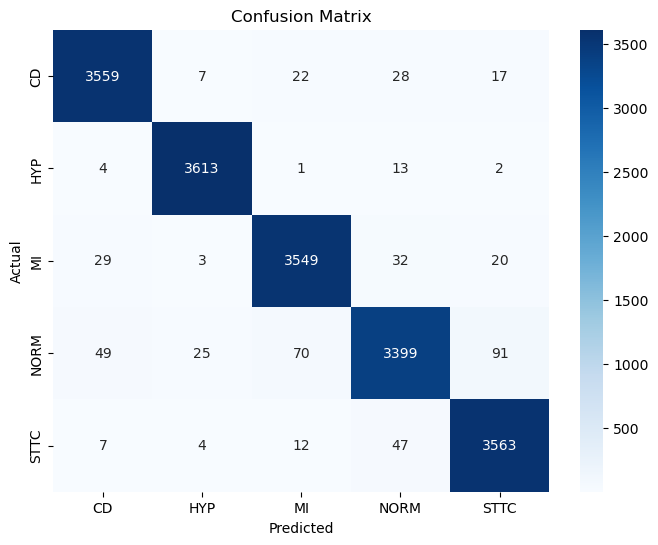

Model input shape: (90830, 500, 12)
Model output shape (classes): torch.Size([54, 5])
Reconstruction output shape: torch.Size([54, 500, 12])
Model saved successfully.


In [29]:
import os

import numpy as np

import wfdb

import torch

import torch.nn as nn

import torch.optim as optim

import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import seaborn as sns

from tqdm import tqdm

from scipy.signal import resample

from sklearn.metrics import f1_score, confusion_matrix

 

# Define your class folders and dataset path

sorted_dataset_path =  r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'

class_folders = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

 

# Function to load data

def load_class_data(sorted_dataset_path, class_folders, sample_rate=100, fraction=1):

    data = []

    labels = []

    errors = []

 

    for label_idx, class_folder in enumerate(class_folders):

        folder_path = os.path.join(sorted_dataset_path, class_folder)

        files = [f for f in os.listdir(folder_path) if f.endswith('.dat')]

 

        num_files = int(len(files) * fraction)

        sampled_files = files[:num_files]

 

        for file in tqdm(sampled_files, desc=f"Loading {class_folder} data ({int(fraction * 100)}%)"):

            file_path = os.path.join(folder_path, file.replace('.dat', ''))

            try:

                signal, _ = wfdb.rdsamp(file_path)

                signal_resampled = resample(signal, 500)  # Resample to 500 samples

                data.append(signal_resampled)

                labels.append(label_idx)

            except Exception as e:

                errors.append(file)

                print(f"Error loading {file}: {e}")

 

    if errors:

        print(f"Skipped {len(errors)} files due to errors.")

 

    return np.array(data), np.array(labels)

 

# Load and split data

X_data, y_labels = load_class_data(sorted_dataset_path, class_folders, fraction=1)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

 

# Define Dataset and DataLoader

class ECGDataset(Dataset):

    def __init__(self, X, y):

        self.X = X

        self.y = y

 

    def __len__(self):

        return len(self.X)

 

    def __getitem__(self, idx):

        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

 

batch_size = 64

train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

test_loader = DataLoader(ECGDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

 

# Capsule Network Implementation

def squash(tensor, dim=-1):

    norm = torch.norm(tensor, dim=dim, keepdim=True)

    scale = (norm ** 2) / (1 + norm ** 2) / (norm + 1e-8)

    return scale * tensor

 

class PrimaryCapsules1D(nn.Module):

    def __init__(self, in_channels, num_capsules, capsule_dim, kernel_size, stride):

        super(PrimaryCapsules1D, self).__init__()

        self.capsules = nn.Conv1d(in_channels, num_capsules * capsule_dim, kernel_size, stride=stride)

        self.num_capsules = num_capsules

        self.capsule_dim = capsule_dim

 

    def forward(self, x):

        x = self.capsules(x)

        batch_size, _, length = x.shape

        x = x.view(batch_size, self.num_capsules, self.capsule_dim, length)

        x = x.permute(0, 1, 3, 2).contiguous().view(batch_size, -1, self.capsule_dim)

        return squash(x)

 

class DigitCapsules(nn.Module):

    def __init__(self, num_capsules, num_routes, in_dim, out_dim, routing_iters=3):

        super(DigitCapsules, self).__init__()

        self.num_capsules = num_capsules  # Number of target capsule types (e.g., number of classes)

        self.num_routes = num_routes      # Number of input capsules from PrimaryCapsules1D

        self.routing_iters = routing_iters

        self.W = nn.Parameter(0.01 * torch.randn(1, num_routes, num_capsules, out_dim, in_dim))

 

    def forward(self, x):

        batch_size = x.size(0)

        x = x.unsqueeze(2).unsqueeze(4).repeat(1, 1, self.num_capsules, 1, 1)

        W = self.W.repeat(batch_size, 1, 1, 1, 1)

 

        u_hat = torch.matmul(W, x).squeeze(-1)

        b_ij = torch.zeros(batch_size, self.num_routes, self.num_capsules, 1).to(x.device)

 

        for _ in range(self.routing_iters):

            c_ij = F.softmax(b_ij, dim=2)

            s_j = (c_ij * u_hat).sum(dim=1)

            v_j = squash(s_j)

            agreement = (u_hat * v_j.unsqueeze(1)).sum(dim=-1, keepdim=True)

            b_ij = b_ij + agreement

 

        return v_j

 

class CapsNet1D(nn.Module):

    def __init__(self, input_dim, num_classes):

        super(CapsNet1D, self).__init__()

        self.conv1 = nn.Conv1d(12, 256, kernel_size=9, stride=1)

        self.primary_capsules = PrimaryCapsules1D(256, 8, 16, kernel_size=9, stride=2)

        self.digit_capsules = DigitCapsules(num_capsules=num_classes, num_routes=1936, in_dim=16, out_dim=16)

        self.decoder = nn.Sequential(

            nn.Linear(16 * num_classes, 512),

            nn.ReLU(True),

            nn.Linear(512, 1024),

            nn.ReLU(True),

            nn.Linear(1024, input_dim * 500 * 12),

            nn.Sigmoid()

        )

 

    def forward(self, x):

        x = x.transpose(1, 2)

        x = F.relu(self.conv1(x))

        x = self.primary_capsules(x)

        x = self.digit_capsules(x)

        classes = torch.norm(x, dim=-1)

        reconstructions = self.decoder(x.view(x.size(0), -1))

        reconstructions = reconstructions.view(-1, 500, 12)

        return classes, reconstructions

 

class CapsuleLoss(nn.Module):

    def __init__(self, lam_recon=0.0005):

        super(CapsuleLoss, self).__init__()

        self.lam_recon = lam_recon

 

    def forward(self, classes, labels, reconstructions, images):

        labels = F.one_hot(labels, num_classes=classes.size(1)).float()

        left = F.relu(0.9 - classes, inplace=True) ** 2

        right = F.relu(classes - 0.1, inplace=True) ** 2

        margin_loss = labels * left + 0.5 * (1.0 - labels) * right

        margin_loss = margin_loss.sum()

        reconstruction_loss = F.mse_loss(reconstructions, images, reduction='sum')

        return margin_loss + self.lam_recon * reconstruction_loss

 

# Set device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

 

# Model setup

model = CapsNet1D(input_dim=1, num_classes=len(class_folders)).to(device)

criterion = CapsuleLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

 

# Training and Evaluation

epochs = 100

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):

        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs, reconstructions = model(inputs)

        loss = criterion(outputs, labels, reconstructions, inputs)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

 

    # Validation phase

    model.eval()

    test_loss, correct, total = 0, 0, 0

    all_labels, all_preds = [], []

    with torch.no_grad():

        for inputs, labels in test_loader:

            inputs, labels = inputs.to(device), labels.to(device)

            outputs, reconstructions = model(inputs)

            loss = criterion(outputs, labels, reconstructions, inputs)

            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())

            all_preds.extend(predicted.cpu().numpy())

 

    accuracy = correct / total

    print(f"Validation Loss: {test_loss / len(test_loader):.4f}, Accuracy: {accuracy:.4f}")

 

# Final evaluation metrics

weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

conf_matrix = confusion_matrix(all_labels, all_preds)

final_test_loss = test_loss / len(test_loader)



print("\nFinal Evaluation Metrics:")

print(f"Weighted F1 Score: {weighted_f1:.4f}")

print(f"Final Testing Accuracy: {accuracy:.4f}")

print(f"Final Testing Loss: {final_test_loss:.4f}")

 

# Confusion Matrix

plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_folders, yticklabels=class_folders)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

 

# Print final input and output shape

print(f"Model input shape: {X_data.shape}")

print(f"Model output shape (classes): {outputs.shape}")

print(f"Reconstruction output shape: {reconstructions.shape}")

 

# Save the model

torch.save(model.state_dict(), r'C:\Users\zen3Node\LEON\myenv\Models\capsule_classification_model100Hz.pth')

print("Model saved successfully.")

Prof Tatiana and Ian NoRouteCapsule

Loading 100% of the data from sorted dataset...


Loading STTC data (100%): 100%|██████████| 18166/18166 [00:58<00:00, 312.74it/s]


Loaded 90830 samples with shape (90830, 1000, 12)
Splitting data into training and test sets...

Epoch 1/100


Training: 100%|██████████| 1136/1136 [00:04<00:00, 240.08it/s]


Train Loss: 0.7566, Train Accuracy: 0.7236
Test Loss: 0.4327, Test Accuracy: 0.8585, Weighted F1: 0.8581

Epoch 2/100


...

Train Loss: 0.0128, Train Accuracy: 0.9987
Test Loss: 0.5956, Test Accuracy: 0.9769, Weighted F1: 0.9768

Epoch 99/100


Training: 100%|██████████| 1136/1136 [00:04<00:00, 248.75it/s]


Train Loss: 0.0061, Train Accuracy: 0.9986
Test Loss: 0.6662, Test Accuracy: 0.9756, Weighted F1: 0.9756

Epoch 100/100


Training: 100%|██████████| 1136/1136 [00:04<00:00, 246.95it/s]


Train Loss: 0.0008, Train Accuracy: 0.9997
Test Loss: 0.6493, Test Accuracy: 0.9768, Weighted F1: 0.9767
Model saved to C:\Users\zen3Node\LEON\myenv\Models\NoRoutecapsule_network_modelx2datas.pth

Final Metrics:
Final Test Loss: 0.6493
Final Test Accuracy: 0.9768
Final Weighted Precision: 0.9768
Final Weighted F1 Score: 0.9767

Confusion Matrix:


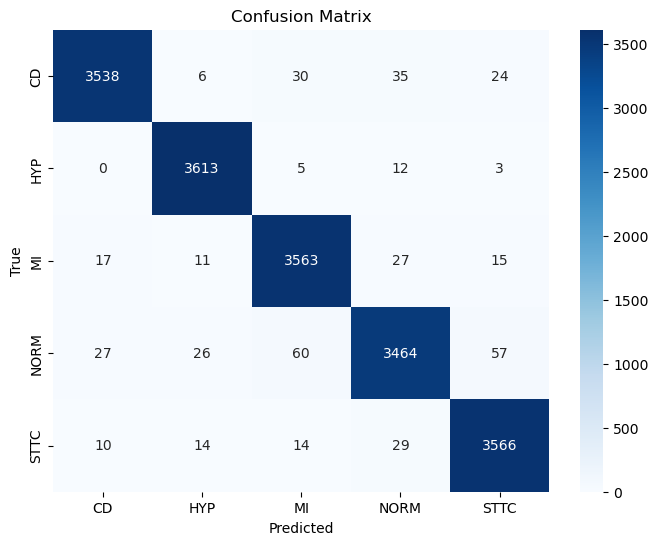


Model Input-Output Shapes:
Input Shape: (18166, 500, 12)
Output Shape: 5


In [30]:
import os
import numpy as np
import wfdb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_fscore_support
from scipy.signal import resample

# Define your dataset path and class folders
sorted_dataset_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'
class_folders = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# Function to load the dataset
def load_class_data(sorted_dataset_path, class_folders, sample_rate=100, fraction=1):
    data = []
    labels = []
    errors = []

    for label_idx, class_folder in enumerate(class_folders):
        folder_path = os.path.join(sorted_dataset_path, class_folder)
        files = [f for f in os.listdir(folder_path) if f.endswith('.dat')]

        num_files = int(len(files) * fraction)
        sampled_files = files[:num_files]

        for file in tqdm(sampled_files, desc=f"Loading {class_folder} data ({int(fraction * 100)}%)"):
            file_path = os.path.join(folder_path, file.replace('.dat', ''))
            try:
                signal, _ = wfdb.rdsamp(file_path)
                data.append(signal)
                labels.append(label_idx)
            except Exception as e:
                errors.append(file)
                print(f"Error loading {file}: {e}")

    if errors:
        print(f"Skipped {len(errors)} files due to errors.")

    return np.array(data), np.array(labels)

# Load data
print("Loading 100% of the data from sorted dataset...")
X_data, y_labels = load_class_data(sorted_dataset_path, class_folders, fraction=1)
print(f"Loaded {X_data.shape[0]} samples with shape {X_data.shape}")

# Resample data to ensure uniform length
X_data_resampled = np.array([resample(x, 500, axis=0) for x in X_data])

# Split the dataset into train and test sets
print("Splitting data into training and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X_data_resampled, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Prepare the data for PyTorch
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

batch_size = 64
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the CapsuleNetwork
class CapsuleNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(CapsuleNetwork, self).__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)

        self.capsule1 = nn.Linear(128 * (500 // 4), 64)
        self.capsule2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)
        x = torch.relu(self.capsule1(x))
        x = self.capsule2(x)

        return x

# Model, loss function, optimizer, and device setup
input_dim = X_train.shape[2]
output_dim = len(class_folders)

model = CapsuleNetwork(input_dim=input_dim, output_dim=output_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 100
for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")

    # Training phase
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")

    # Validation phase
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    test_loss /= len(test_loader)
    accuracy = correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {accuracy:.4f}, Weighted F1: {f1:.4f}")

# Save the model
model_path = r"C:\Users\zen3Node\LEON\myenv\Models\NoRoutecapsule_network_modelx2datas.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

# Final Evaluation
model.eval()
test_loss, correct, total = 0.0, 0, 0
all_labels, all_preds = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

test_loss /= len(test_loader)
accuracy = correct / total
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted"
)

# Print final metrics
print("\nFinal Metrics:")
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {accuracy:.4f}")
print(f"Final Weighted Precision: {precision:.4f}")
print(f"Final Weighted F1 Score: {f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
class_names = class_folders

print("\nConfusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Input and output shape
input_shape = X_test.shape
output_shape = output_dim

print("\nModel Input-Output Shapes:")
print(f"Input Shape: {input_shape}")
print(f"Output Shape: {output_shape}")


LSTM max learning Double data

Loading 100% of the data from sorted dataset...


Loading STTC data (100%): 100%|██████████| 18166/18166 [01:04<00:00, 282.73it/s]


Loaded 90830 samples with shape (90830, 500, 12)
Splitting data into training and test sets...
Training set: (72664, 500, 12), Test set: (18166, 500, 12)

Epoch 1/100


Training: 100%|██████████| 1136/1136 [00:12<00:00, 89.24it/s] 


Training loss: 1.6096, Training Accuracy: 0.2035


...

Training loss: 0.2292, Training Accuracy: 0.9225
Validation loss: 0.2369, Testing Accuracy: 0.9283, Weighted F1 Score: 0.9281
Classification Report:
CD    - Precision: 0.93, Recall: 0.91, F1-score: 0.92, Support: 3633
HYP   - Precision: 0.97, Recall: 0.98, F1-score: 0.97, Support: 3633
MI    - Precision: 0.92, Recall: 0.91, F1-score: 0.92, Support: 3633
NORM  - Precision: 0.91, Recall: 0.88, F1-score: 0.90, Support: 3634
STTC  - Precision: 0.91, Recall: 0.95, F1-score: 0.93, Support: 3633

Epoch 99/100


Training: 100%|██████████| 1136/1136 [00:11<00:00, 100.68it/s]


Training loss: 0.2192, Training Accuracy: 0.9262
Validation loss: 0.2723, Testing Accuracy: 0.9123, Weighted F1 Score: 0.9121
Classification Report:
CD    - Precision: 0.95, Recall: 0.88, F1-score: 0.91, Support: 3633
HYP   - Precision: 0.95, Recall: 0.99, F1-score: 0.97, Support: 3633
MI    - Precision: 0.94, Recall: 0.87, F1-score: 0.90, Support: 3633
NORM  - Precision: 0.86, Recall: 0.88, F1-score: 0.87, Support: 3634
STTC  - Precision: 0.87, Recall: 0.95, F1-score: 0.91, Support: 3633

Epoch 100/100


Training: 100%|██████████| 1136/1136 [00:11<00:00, 100.09it/s]


Training loss: 0.2655, Training Accuracy: 0.9051
Validation loss: 0.3569, Testing Accuracy: 0.8677, Weighted F1 Score: 0.8679
Classification Report:
CD    - Precision: 0.79, Recall: 0.87, F1-score: 0.82, Support: 3633
HYP   - Precision: 0.94, Recall: 0.91, F1-score: 0.92, Support: 3633
MI    - Precision: 0.91, Recall: 0.88, F1-score: 0.89, Support: 3633
NORM  - Precision: 0.88, Recall: 0.78, F1-score: 0.83, Support: 3634
STTC  - Precision: 0.84, Recall: 0.90, F1-score: 0.87, Support: 3633


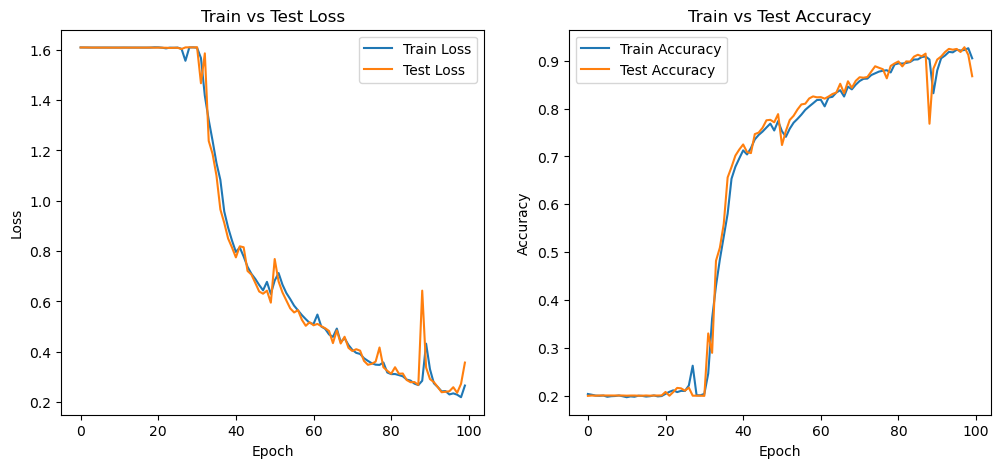

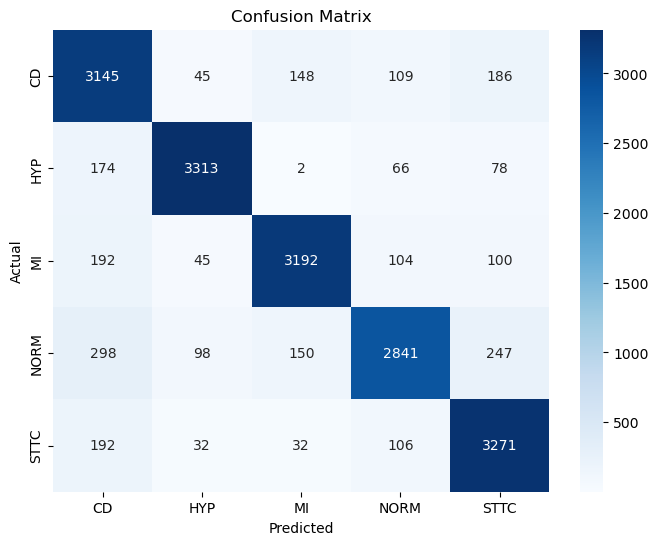


Final Weighted F1 Score: 0.8679
Final Test Loss: 0.3569
Final Test Accuracy: 0.8677
Final Input Shape: (90830, 500, 12)
Model saved to C:\Users\zen3Node\LEON\myenv\Models\lstm_classification_model_maxlearningx2datas(100Hz).pth


In [31]:
import os
import numpy as np
import wfdb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.signal import resample
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_fscore_support

# Define your class folders and dataset path
sorted_dataset_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'
class_folders = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# Function to load 100% of the data from each class folder without random sampling
def load_class_data(sorted_dataset_path, class_folders, sample_rate=100, fraction=1):
    data = []
    labels = []
    errors = []

    for label_idx, class_folder in enumerate(class_folders):
        folder_path = os.path.join(sorted_dataset_path, class_folder)
        files = [f for f in os.listdir(folder_path) if f.endswith('.dat')]

        # Load all files without sampling
        for file in tqdm(files, desc=f"Loading {class_folder} data (100%)"):
            file_path = os.path.join(folder_path, file.replace('.dat', ''))
            try:
                signal, _ = wfdb.rdsamp(file_path)
                signal_resampled = resample(signal, 500)  # Resample the signal to 500 samples
                data.append(signal_resampled)
                labels.append(label_idx)
            except Exception as e:
                errors.append(file)
                print(f"Error loading {file}: {e}")

    if errors:
        print(f"Skipped {len(errors)} files due to errors.")

    return np.array(data), np.array(labels)

# Load 100% of the data from the specified folders
print("Loading 100% of the data from sorted dataset...")
X_data, y_labels = load_class_data(sorted_dataset_path, class_folders, fraction=1)
print(f"Loaded {X_data.shape[0]} samples with shape {X_data.shape}")

# Split the dataset into train and test sets (80-20 split)
print("Splitting data into training and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

# Print the shapes of the train/test sets
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Prepare the data for PyTorch by creating a Dataset and DataLoader
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# Create DataLoader for batch processing
batch_size = 64
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the LSTM model with increased layers
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=4):  # Increased num_layers to 4
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])  # Use the last hidden state
        return out

# Model, loss function, optimizer, and device setup
input_dim = X_train.shape[2]  # Number of ECG leads (input channels)
hidden_dim = 64  # Number of hidden units
output_dim = len(class_folders)  # Number of classes
num_layers = 4  # Increased the number of layers

model = LSTMModel(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Lists to store losses, accuracy, and F1 scores
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
f1_scores = []

# Training loop
epochs = 100
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # Training phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        # Pass the labels into the criterion
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Calculate training accuracy
    train_accuracy = correct_train / total_train
    train_accuracies.append(train_accuracy)

    print(f"Training loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

    # Validation phase
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Collect all labels and predictions for F1 score calculation
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    accuracy = correct / total
    test_accuracies.append(accuracy)

    # Calculate precision, recall, f1-score, and support for each class
    precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=np.arange(len(class_folders)))

    # Weighted average F1 score
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    f1_scores.append(weighted_f1)

    # Print the detailed classification report
    print(f"Validation loss: {test_loss:.4f}, Testing Accuracy: {accuracy:.4f}, Weighted F1 Score: {weighted_f1:.4f}")
    print("Classification Report:")
    for i, class_name in enumerate(class_folders):
        print(f"{class_name:5} - Precision: {precision[i]:.2f}, Recall: {recall[i]:.2f}, F1-score: {f1[i]:.2f}, Support: {support[i]}")

# Plot training vs validation loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_folders, yticklabels=class_folders)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Print final metrics
print(f"\nFinal Weighted F1 Score: {f1_scores[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")
print(f"Final Test Accuracy: {test_accuracies[-1]:.4f}")
print(f"Final Input Shape: {X_data.shape}")

# Save the model
model_save_path = r'C:\Users\zen3Node\LEON\myenv\Models\lstm_classification_model_maxlearningx2datas(100Hz).pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

GRU max lerning double data

Loading STTC data: 100%|██████████| 18166/18166 [01:21<00:00, 222.69it/s]


Loaded 90830 samples with shape (90830, 500, 12)
Training set: (72664, 500, 12), Test set: (18166, 500, 12)

Epoch 1/100


Training: 100%|██████████| 1136/1136 [00:17<00:00, 66.60it/s]


Training loss: 1.2063, Training Accuracy: 0.4982
Validation loss: 0.8974, Testing Accuracy: 0.6757, Weighted F1 Score: 0.6778
Classification Report:
CD    - Precision: 0.78, Recall: 0.60, F1-score: 0.68, Support: 3633
HYP   - Precision: 0.77, Recall: 0.69, F1-score: 0.73, Support: 3633
MI    - Precision: 0.56, Recall: 0.65, F1-score: 0.60, Support: 3633
NORM  - Precision: 0.73, Recall: 0.70, F1-score: 0.72, Support: 3634
STTC  - Precision: 0.61, Recall: 0.73, F1-score: 0.66, Support: 3633

Epoch 2/100


Training: 100%|██████████| 1136/1136 [00:16<00:00, 67.73it/s]


...

Training loss: 0.1144, Training Accuracy: 0.9632
Validation loss: 0.1555, Testing Accuracy: 0.9575, Weighted F1 Score: 0.9573
Classification Report:
CD    - Precision: 0.94, Recall: 0.97, F1-score: 0.96, Support: 3633
HYP   - Precision: 0.97, Recall: 0.99, F1-score: 0.98, Support: 3633
MI    - Precision: 0.96, Recall: 0.96, F1-score: 0.96, Support: 3633
NORM  - Precision: 0.96, Recall: 0.90, F1-score: 0.93, Support: 3634
STTC  - Precision: 0.95, Recall: 0.97, F1-score: 0.96, Support: 3633

Epoch 99/100


Training: 100%|██████████| 1136/1136 [00:16<00:00, 70.12it/s]


Training loss: 0.1181, Training Accuracy: 0.9608
Validation loss: 0.1706, Testing Accuracy: 0.9510, Weighted F1 Score: 0.9509
Classification Report:
CD    - Precision: 0.97, Recall: 0.93, F1-score: 0.95, Support: 3633
HYP   - Precision: 0.97, Recall: 0.98, F1-score: 0.98, Support: 3633
MI    - Precision: 0.91, Recall: 0.98, F1-score: 0.94, Support: 3633
NORM  - Precision: 0.95, Recall: 0.90, F1-score: 0.93, Support: 3634
STTC  - Precision: 0.95, Recall: 0.95, F1-score: 0.95, Support: 3633

Epoch 100/100


Training: 100%|██████████| 1136/1136 [00:16<00:00, 70.34it/s]


Training loss: 0.1222, Training Accuracy: 0.9593
Validation loss: 0.1586, Testing Accuracy: 0.9555, Weighted F1 Score: 0.9554
Classification Report:
CD    - Precision: 0.96, Recall: 0.95, F1-score: 0.95, Support: 3633
HYP   - Precision: 0.97, Recall: 0.99, F1-score: 0.98, Support: 3633
MI    - Precision: 0.96, Recall: 0.96, F1-score: 0.96, Support: 3633
NORM  - Precision: 0.94, Recall: 0.92, F1-score: 0.93, Support: 3634
STTC  - Precision: 0.95, Recall: 0.96, F1-score: 0.96, Support: 3633


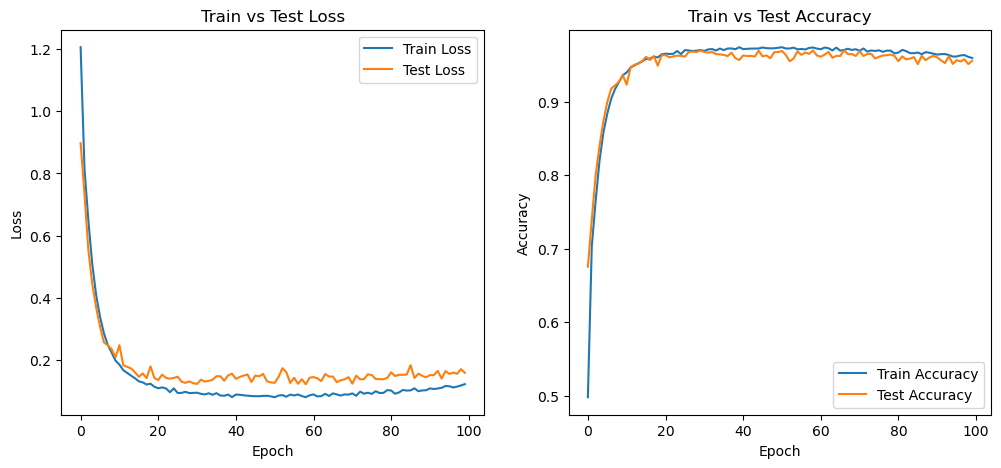

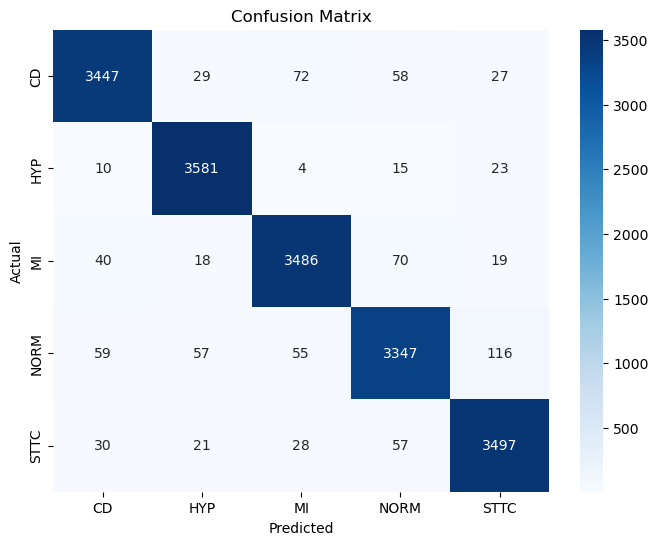


Final Report:
Final Input Shape: (72664, 500, 12)
Final Weighted F1 Score: 0.9554
Final Test Loss: 0.1586
Final Test Accuracy: 0.9555
Model saved to C:\Users\zen3Node\LEON\myenv\Models\gru_ecg_classification_modelMaxLearnx2datas(100Hz).pth


In [32]:
import os
import numpy as np
import wfdb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.signal import resample
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_fscore_support

# Define your class folders and dataset path
sorted_dataset_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'
class_folders = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# Function to load data and resample to 100 Hz
def load_class_data(sorted_dataset_path, class_folders, sample_rate=100, fraction=1):
    data = []
    labels = []
    errors = []

    for label_idx, class_folder in enumerate(class_folders):
        folder_path = os.path.join(sorted_dataset_path, class_folder)
        files = [f for f in os.listdir(folder_path) if f.endswith('.dat')]

        num_files = int(len(files) * fraction)
        sampled_files = files[:num_files]

        for file in tqdm(sampled_files, desc=f"Loading {class_folder} data"):
            file_path = os.path.join(folder_path, file.replace('.dat', ''))
            try:
                signal, _ = wfdb.rdsamp(file_path)
                signal_resampled = resample(signal, 500)  # Resample to 500 samples
                data.append(signal_resampled)
                labels.append(label_idx)
            except Exception as e:
                errors.append(file)
                print(f"Error loading {file}: {e}")

    if errors:
        print(f"Skipped {len(errors)} files due to errors.")

    return np.array(data), np.array(labels)

# Load the data
X_data, y_labels = load_class_data(sorted_dataset_path, class_folders, sample_rate=100, fraction=1)
print(f"Loaded {X_data.shape[0]} samples with shape {X_data.shape}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.2, random_state=42, stratify=y_labels)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Prepare the data for PyTorch by creating a Dataset and DataLoader
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

batch_size = 64
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define GRU Model for Multi-class Classification with ReLU activation
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=4, dropout_rate=0.5):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout_rate)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()  # ReLU activation after GRU layer

    def forward(self, x):
        gru_out, _ = self.gru(x)
        out = self.relu(gru_out[:, -1, :])  # Apply ReLU after GRU
        out = self.dropout(out)
        out = self.fc(out)  # No softmax, handled by CrossEntropyLoss
        return out

# Model, loss function, optimizer, and device setup
input_dim = X_train.shape[2]  # Number of ECG leads (input channels)
hidden_dim = 128  # Hidden state size
output_dim = len(class_folders)  # Number of output classes (classification)

model = GRUModel(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, dropout_rate=0.2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()  # Multi-class classification loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with progress tracking
epochs = 100
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
f1_scores = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # Training phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    train_accuracy = correct_train / total_train
    train_accuracies.append(train_accuracy)

    print(f"Training loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

    # Validation phase
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    accuracy = correct / total
    test_accuracies.append(accuracy)

    precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=np.arange(len(class_folders)))
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    f1_scores.append(weighted_f1)

    print(f"Validation loss: {test_loss:.4f}, Testing Accuracy: {accuracy:.4f}, Weighted F1 Score: {weighted_f1:.4f}")
    print("Classification Report:")
    for i, class_name in enumerate(class_folders):
        print(f"{class_name:5} - Precision: {precision[i]:.2f}, Recall: {recall[i]:.2f}, F1-score: {f1[i]:.2f}, Support: {support[i]}")

# Plot training vs validation loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()

plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_folders, yticklabels=class_folders)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Final Report
print("\nFinal Report:")
print(f"Final Input Shape: {X_train.shape}")
print(f"Final Weighted F1 Score: {f1_scores[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")
print(f"Final Test Accuracy: {test_accuracies[-1]:.4f}")

# Save the model
model_save_path = r'C:\Users\zen3Node\LEON\myenv\Models\gru_ecg_classification_modelMaxLearnx2datas(100Hz).pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")


ResNet 1D time series

Loading 100% of the data from sorted dataset...


Loading STTC data (100%): 100%|██████████| 18166/18166 [01:20<00:00, 226.89it/s]


Loaded 90830 samples with shape (90830, 500, 12)
Splitting data into training and test sets...
Training set: (72664, 500, 12), Test set: (18166, 500, 12)

Epoch 1/100


Training: 100%|██████████| 1136/1136 [00:05<00:00, 226.09it/s]


Training loss: 0.8216, Training Accuracy: 0.6955
Validation loss: 0.4405, Testing Accuracy: 0.8548, Weighted F1 Score: 0.8549
Classification Report:
CD    - Precision: 0.91, Recall: 0.81, F1-score: 0.86, Support: 3633
HYP   - Precision: 0.95, Recall: 0.94, F1-score: 0.94, Support: 3633
MI    - Precision: 0.83, Recall: 0.83, F1-score: 0.83, Support: 3633
NORM  - Precision: 0.84, Recall: 0.78, F1-score: 0.81, Support: 3634
STTC  - Precision: 0.77, Recall: 0.92, F1-score: 0.84, Support: 3633

Epoch 2/100


...

Training loss: 0.0219, Training Accuracy: 0.9945
Validation loss: 0.3385, Testing Accuracy: 0.9813, Weighted F1 Score: 0.9813
Classification Report:
CD    - Precision: 0.99, Recall: 0.98, F1-score: 0.98, Support: 3633
HYP   - Precision: 0.99, Recall: 0.99, F1-score: 0.99, Support: 3633
MI    - Precision: 0.97, Recall: 0.98, F1-score: 0.98, Support: 3633
NORM  - Precision: 0.97, Recall: 0.96, F1-score: 0.97, Support: 3634
STTC  - Precision: 0.98, Recall: 0.98, F1-score: 0.98, Support: 3633

Epoch 99/100


Training: 100%|██████████| 1136/1136 [00:04<00:00, 235.02it/s]


Training loss: 0.0250, Training Accuracy: 0.9931
Validation loss: 0.3260, Testing Accuracy: 0.9790, Weighted F1 Score: 0.9790
Classification Report:
CD    - Precision: 0.98, Recall: 0.98, F1-score: 0.98, Support: 3633
HYP   - Precision: 0.98, Recall: 1.00, F1-score: 0.99, Support: 3633
MI    - Precision: 0.98, Recall: 0.98, F1-score: 0.98, Support: 3633
NORM  - Precision: 0.98, Recall: 0.96, F1-score: 0.97, Support: 3634
STTC  - Precision: 0.97, Recall: 0.98, F1-score: 0.98, Support: 3633

Epoch 100/100


Training: 100%|██████████| 1136/1136 [00:04<00:00, 233.65it/s]


Training loss: 0.0244, Training Accuracy: 0.9934
Validation loss: 0.3457, Testing Accuracy: 0.9798, Weighted F1 Score: 0.9798
Classification Report:
CD    - Precision: 0.99, Recall: 0.98, F1-score: 0.98, Support: 3633
HYP   - Precision: 0.99, Recall: 1.00, F1-score: 0.99, Support: 3633
MI    - Precision: 0.97, Recall: 0.98, F1-score: 0.98, Support: 3633
NORM  - Precision: 0.98, Recall: 0.96, F1-score: 0.97, Support: 3634
STTC  - Precision: 0.98, Recall: 0.98, F1-score: 0.98, Support: 3633


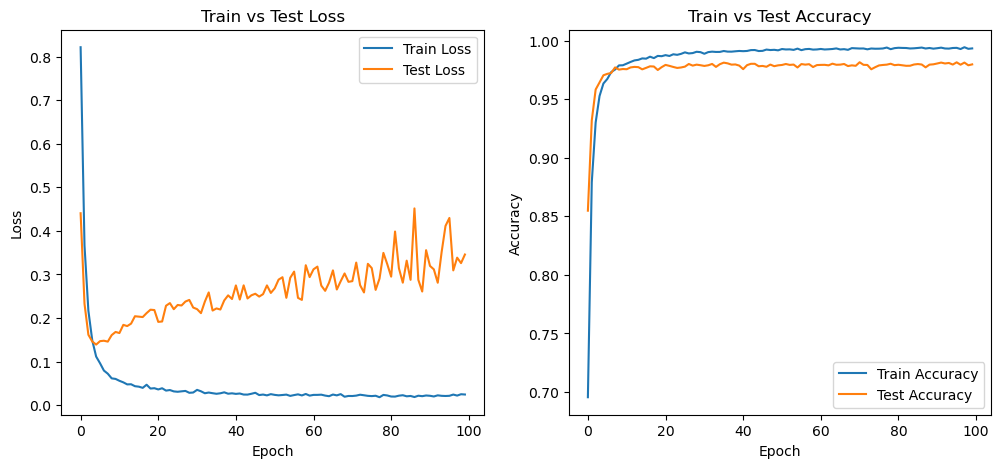

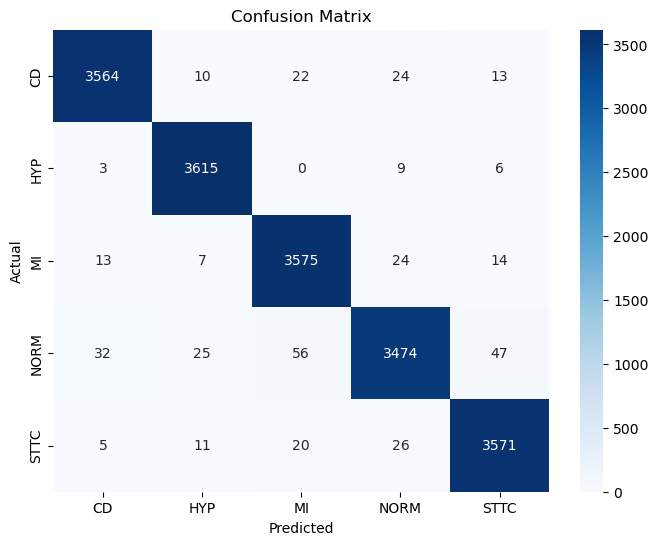

Model saved to C:\Users\zen3Node\LEON\myenv\Models\Resnet1D_classification_model_transferlearningx2data100Hz.pth

Final Input Shape: (72664, 500, 12)
Final Training Loss: 0.0244
Final Testing Loss: 0.3457
Final Training Accuracy: 0.9934
Final Testing Accuracy: 0.9798
Final Weighted F1 Score: 0.9798


In [33]:
import os
import numpy as np
import wfdb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.signal import resample
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_fscore_support

# Define your class folders and dataset path
sorted_dataset_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'
class_folders = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# Function to load 100% of the data from each class folder
def load_class_data(sorted_dataset_path, class_folders, sample_rate=100, fraction=1):
    data = []
    labels = []
    errors = []

    for label_idx, class_folder in enumerate(class_folders):
        folder_path = os.path.join(sorted_dataset_path, class_folder)
        files = [f for f in os.listdir(folder_path) if f.endswith('.dat')]

        num_files = int(len(files) * fraction)
        sampled_files = files[:num_files]

        for file in tqdm(sampled_files, desc=f"Loading {class_folder} data ({int(fraction * 100)}%)"):
            file_path = os.path.join(folder_path, file.replace('.dat', ''))
            try:
                signal, _ = wfdb.rdsamp(file_path)
                signal_resampled = resample(signal, 500)  # Resample to 500 samples
                data.append(signal_resampled)
                labels.append(label_idx)
            except Exception as e:
                errors.append(file)
                print(f"Error loading {file}: {e}")

    if errors:
        print(f"Skipped {len(errors)} files due to errors.")

    return np.array(data), np.array(labels)

# Load 100% of the data (all .dat files)
print("Loading 100% of the data from sorted dataset...")
X_data, y_labels = load_class_data(sorted_dataset_path, class_folders, fraction=1)
print(f"Loaded {X_data.shape[0]} samples with shape {X_data.shape}")

# Split the dataset into train and test sets (80-20 split)
print("Splitting data into training and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Prepare the data for PyTorch by creating a Dataset and DataLoader
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# Create DataLoader for batch processing
batch_size = 64
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define CNN model for time series classification
class CNNModel(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_rate=0.5):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(dropout_rate)

        self.fc1_input_dim = 128 * (500 // 4)
        self.fc1 = nn.Linear(self.fc1_input_dim, 128)
        self.fc2 = nn.Linear(128, output_dim)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Model, loss function, optimizer, and device setup
input_dim = X_train.shape[2]
output_dim = len(class_folders)

model = CNNModel(input_dim=input_dim, output_dim=output_dim, dropout_rate=0.5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
f1_scores = []

# Training loop
epochs = 100
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    train_accuracy = correct_train / total_train
    train_accuracies.append(train_accuracy)

    print(f"Training loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())``
            all_preds.extend(predicted.cpu().numpy())

    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    accuracy = correct / total
    test_accuracies.append(accuracy)

    precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=np.arange(len(class_folders)))

    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    f1_scores.append(weighted_f1)

    print(f"Validation loss: {test_loss:.4f}, Testing Accuracy: {accuracy:.4f}, Weighted F1 Score: {weighted_f1:.4f}")
    print("Classification Report:")
    for i, class_name in enumerate(class_folders):
        print(f"{class_name:5} - Precision: {precision[i]:.2f}, Recall: {recall[i]:.2f}, F1-score: {f1[i]:.2f}, Support: {support[i]}")

# Plot training vs validation loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()

plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_folders, yticklabels=class_folders)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Save the model
model_save_path = r'C:\Users\zen3Node\LEON\myenv\Models\Resnet1D_classification_model_transferlearningx2data100Hz.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# Final metrics
print(f"\nFinal Input Shape: {X_train.shape}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Testing Loss: {test_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Testing Accuracy: {test_accuracies[-1]:.4f}")
print(f"Final Weighted F1 Score: {f1_scores[-1]:.4f}")


CNN Max Learn Double Data

Loading 100% of the data from sorted dataset...


Loading STTC data (100%): 100%|██████████| 18166/18166 [01:17<00:00, 234.70it/s]


Loaded 90830 samples with shape (90830, 500, 12)
Splitting data into training and test sets...
Training set: (72664, 500, 12), Test set: (18166, 500, 12)

Epoch 1/100


Training: 100%|██████████| 1136/1136 [00:05<00:00, 226.53it/s]


Training loss: 0.8188, Training Accuracy: 0.6983
Validation loss: 0.4183, Testing Accuracy: 0.8631, Weighted F1 Score: 0.8629
Classification Report:
CD    - Precision: 0.89, Recall: 0.84, F1-score: 0.86, Support: 3633
HYP   - Precision: 0.93, Recall: 0.95, F1-score: 0.94, Support: 3633
MI    - Precision: 0.89, Recall: 0.78, F1-score: 0.83, Support: 3633
NORM  - Precision: 0.79, Recall: 0.86, F1-score: 0.82, Support: 3634
STTC  - Precision: 0.83, Recall: 0.89, F1-score: 0.86, Support: 3633

Epoch 2/100


...

Training loss: 0.0179, Training Accuracy: 0.9947
Validation loss: 0.3267, Testing Accuracy: 0.9770, Weighted F1 Score: 0.9769
Classification Report:
CD    - Precision: 0.97, Recall: 0.98, F1-score: 0.98, Support: 3633
HYP   - Precision: 0.98, Recall: 1.00, F1-score: 0.99, Support: 3633
MI    - Precision: 0.98, Recall: 0.98, F1-score: 0.98, Support: 3633
NORM  - Precision: 0.98, Recall: 0.94, F1-score: 0.96, Support: 3634
STTC  - Precision: 0.97, Recall: 0.98, F1-score: 0.98, Support: 3633

Epoch 99/100


Training: 100%|██████████| 1136/1136 [00:04<00:00, 233.67it/s]


Training loss: 0.0224, Training Accuracy: 0.9938
Validation loss: 0.3388, Testing Accuracy: 0.9798, Weighted F1 Score: 0.9798
Classification Report:
CD    - Precision: 0.98, Recall: 0.98, F1-score: 0.98, Support: 3633
HYP   - Precision: 0.99, Recall: 1.00, F1-score: 0.99, Support: 3633
MI    - Precision: 0.97, Recall: 0.98, F1-score: 0.98, Support: 3633
NORM  - Precision: 0.98, Recall: 0.96, F1-score: 0.97, Support: 3634
STTC  - Precision: 0.98, Recall: 0.98, F1-score: 0.98, Support: 3633

Epoch 100/100


Training: 100%|██████████| 1136/1136 [00:04<00:00, 232.62it/s]


Training loss: 0.0179, Training Accuracy: 0.9947
Validation loss: 0.4551, Testing Accuracy: 0.9795, Weighted F1 Score: 0.9795
Classification Report:
CD    - Precision: 0.99, Recall: 0.98, F1-score: 0.98, Support: 3633
HYP   - Precision: 0.99, Recall: 1.00, F1-score: 0.99, Support: 3633
MI    - Precision: 0.98, Recall: 0.98, F1-score: 0.98, Support: 3633
NORM  - Precision: 0.97, Recall: 0.96, F1-score: 0.97, Support: 3634
STTC  - Precision: 0.97, Recall: 0.98, F1-score: 0.98, Support: 3633


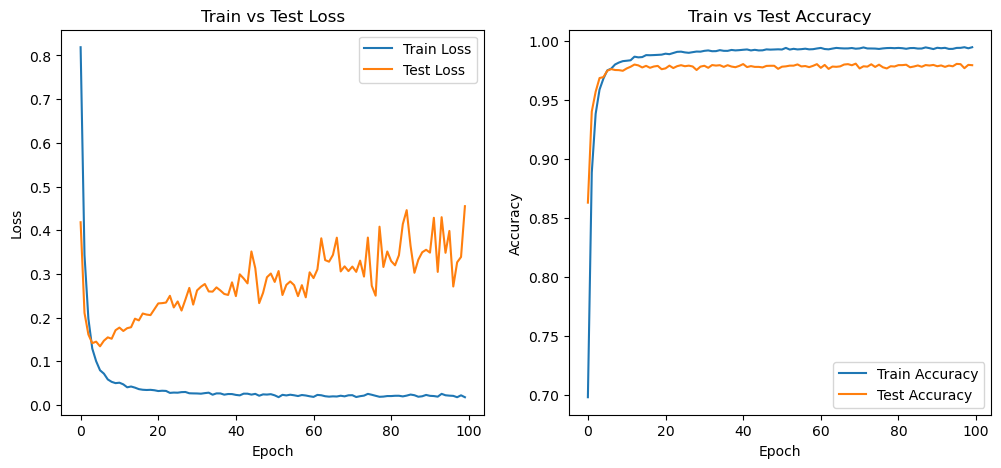

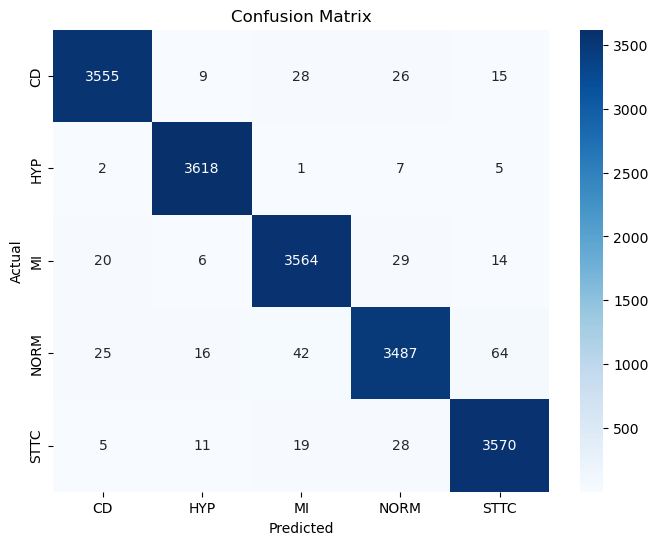


Final Weighted F1 Score: 0.9795
Final Testing Accuracy: 0.9795
Final Testing Loss: 0.4551
Input Shape: (90830, 500, 12)
Model saved to C:\Users\zen3Node\LEON\myenv\Models\cnn_classification_model_maxlearningx2datas(100Hz).pth


In [34]:
import os
import numpy as np
import wfdb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.signal import resample
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_fscore_support

# Define your class folders and dataset path
sorted_dataset_path = r'C:\Users\zen3Node\LEON\myenv\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\SortedByClass'
class_folders = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# Function to load 100% of the data from each class folder
def load_class_data(sorted_dataset_path, class_folders, sample_rate=100, fraction=1):
    data = []
    labels = []
    errors = []

    for label_idx, class_folder in enumerate(class_folders):
        folder_path = os.path.join(sorted_dataset_path, class_folder)
        files = [f for f in os.listdir(folder_path) if f.endswith('.dat')]

        # Load 100% of the files (fraction=1 means all files)
        num_files = int(len(files) * fraction)
        sampled_files = files[:num_files]

        for file in tqdm(sampled_files, desc=f"Loading {class_folder} data ({int(fraction * 100)}%)"):
            file_path = os.path.join(folder_path, file.replace('.dat', ''))
            try:
                signal, _ = wfdb.rdsamp(file_path)
                signal_resampled = resample(signal, 500)  # Resample to 500 samples
                data.append(signal_resampled)
                labels.append(label_idx)
            except Exception as e:
                errors.append(file)
                print(f"Error loading {file}: {e}")

    if errors:
        print(f"Skipped {len(errors)} files due to errors.")

    return np.array(data), np.array(labels)

# Load 100% of the data (all .dat files)
print("Loading 100% of the data from sorted dataset...")
X_data, y_labels = load_class_data(sorted_dataset_path, class_folders, fraction=1)
print(f"Loaded {X_data.shape[0]} samples with shape {X_data.shape}")

# Split the dataset into train and test sets (80-20 split)
print("Splitting data into training and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

# Print the shapes of the train/test sets
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Prepare the data for PyTorch by creating a Dataset and DataLoader
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

# Create DataLoader for batch processing
batch_size = 64
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define CNN model for time series classification with Dropout and Activation Functions
class CNNModel(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_rate=0.5):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(dropout_rate)

        # Calculate input size for fully connected layer
        self.fc1_input_dim = 128 * (500 // 4)
        self.fc1 = nn.Linear(self.fc1_input_dim, 128)
        self.fc2 = nn.Linear(128, output_dim)

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Model, loss function, optimizer, and device setup
input_dim = X_train.shape[2]
output_dim = len(class_folders)

model = CNNModel(input_dim=input_dim, output_dim=output_dim, dropout_rate=0.5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Lists to store losses, accuracy, and F1 scores
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
f1_scores = []

# Training loop
epochs = 100
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # Training phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        # Pass the labels into the criterion
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Calculate training accuracy
    train_accuracy = correct_train / total_train
    train_accuracies.append(train_accuracy)

    print(f"Training loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

    # Validation phase
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Collect all labels and predictions for F1 score calculation
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    accuracy = correct / total
    test_accuracies.append(accuracy)

    # Calculate precision, recall, f1-score, and support for each class
    precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=np.arange(len(class_folders)))

    # Weighted average F1 score
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    f1_scores.append(weighted_f1)

    # Print the detailed classification report
    print(f"Validation loss: {test_loss:.4f}, Testing Accuracy: {accuracy:.4f}, Weighted F1 Score: {weighted_f1:.4f}")
    print("Classification Report:")
    for i, class_name in enumerate(class_folders):
        print(f"{class_name:5} - Precision: {precision[i]:.2f}, Recall: {recall[i]:.2f}, F1-score: {f1[i]:.2f}, Support: {support[i]}")

# Plot training vs validation loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()

plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_folders, yticklabels=class_folders)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Print final results
print(f"\nFinal Weighted F1 Score: {f1_scores[-1]:.4f}")
print(f"Final Testing Accuracy: {test_accuracies[-1]:.4f}")
print(f"Final Testing Loss: {test_losses[-1]:.4f}")
print(f"Input Shape: {X_data.shape}")

# Save the model
model_save_path = r'C:\Users\zen3Node\LEON\myenv\Models\cnn_classification_model_maxlearningx2datas(100Hz).pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")
